In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid", palette="cool")


In [2]:
df = pd.read_csv("synthetic_task_dataset.csv")
print(df.shape)
df.head()
df.columns


(1500, 10)


Index(['task_id', 'task_title', 'task_description', 'priority', 'deadline',
       'assigned_to', 'status', 'category', 'estimated_hours', 'created_at'],
      dtype='object')

In [3]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   task_id           1500 non-null   int64  
 1   task_title        1500 non-null   object 
 2   task_description  1500 non-null   object 
 3   priority          1500 non-null   object 
 4   deadline          1500 non-null   object 
 5   assigned_to       1500 non-null   object 
 6   status            1500 non-null   object 
 7   category          1500 non-null   object 
 8   estimated_hours   1500 non-null   float64
 9   created_at        1500 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 117.3+ KB


task_id             0
task_title          0
task_description    0
priority            0
deadline            0
assigned_to         0
status              0
category            0
estimated_hours     0
created_at          0
dtype: int64

In [4]:
for col in ["priority", "status", "category", "assigned_to"]:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())



Value counts for priority:
priority
Low         420
Critical    379
Medium      357
High        344
Name: count, dtype: int64

Value counts for status:
status
Completed      380
On Hold        380
In Progress    376
Pending        364
Name: count, dtype: int64

Value counts for category:
category
Feature          319
Bug Fix          309
Testing          305
UI/UX            286
Documentation    281
Name: count, dtype: int64

Value counts for assigned_to:
assigned_to
Shan    324
Akin    305
Jo      297
Dia     294
Jane    280
Name: count, dtype: int64


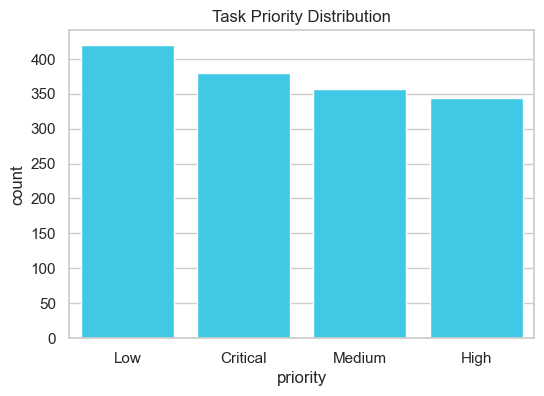

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="priority", order=df["priority"].value_counts().index)
plt.title("Task Priority Distribution")
plt.show()


C:\Users\Smile\AppData\Local\Temp\ipykernel_10040\1959243326.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="status", palette="viridis")


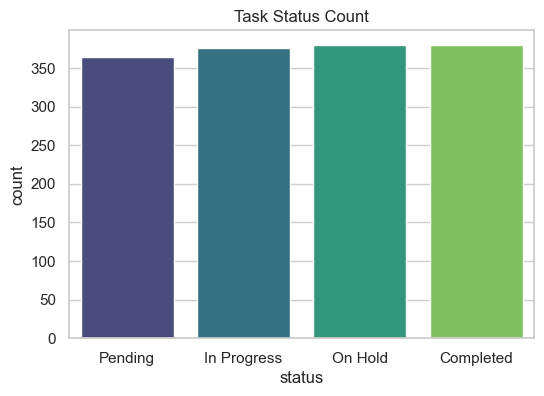

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="status", palette="viridis")
plt.title("Task Status Count")
plt.show()


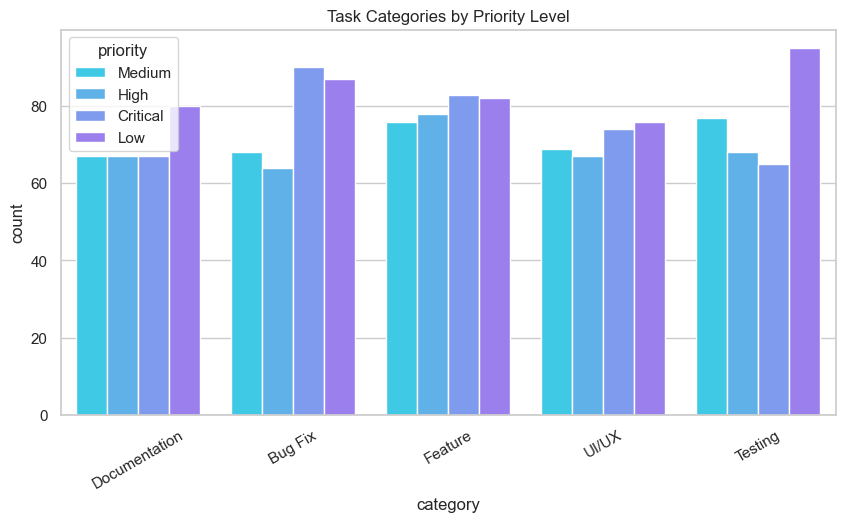

In [7]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="category", hue="priority")
plt.title("Task Categories by Priority Level")
plt.xticks(rotation=30)
plt.show()


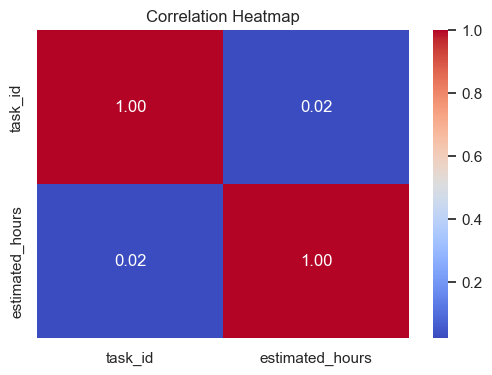

In [8]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


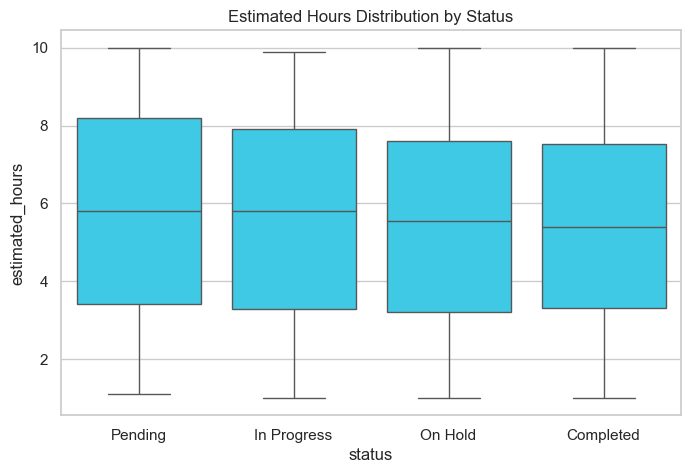

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="status", y="estimated_hours")
plt.title("Estimated Hours Distribution by Status")
plt.show()


In [10]:

df['deadline'] = pd.to_datetime(df['deadline'])
df['created_at'] = pd.to_datetime(df['created_at'])


df['days_left'] = (df['deadline'] - pd.Timestamp.today()).dt.days
df['task_length'] = df['task_description'].apply(len)


df[['task_title', 'days_left', 'task_length']].head()


,task_title,days_left,task_length
0,Opportunity item indicate.,4,100
1,Wish article hand.,24,99
2,Dinner system.,26,52
3,Sort right parent.,21,106
4,Type knowledge question there drive.,2,99


In [11]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import string


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')  
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Smile\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Smile\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Smile\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Smile\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [13]:

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1️⃣ lowercase
    text = text.lower()

    # 2️⃣ remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 3️⃣ tokenize
    tokens = word_tokenize(text)

    # 4️⃣ remove stopwords & short words
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

    # 5️⃣ stemming
    stemmed = [stemmer.stem(word) for word in filtered_tokens]

    # 6️⃣ join back to string
    return " ".join(stemmed)


In [14]:
df['cleaned_description'] = df['task_description'].apply(preprocess_text)
df[['task_description', 'cleaned_description']].head(10)



,task_description,cleaned_description
0,Property agreement position. Decide hundred cl...,properti agreement posit decid hundr claim pho...
1,Listen forward young common nice image. Yeah v...,listen forward young common nice imag yeah vot...
2,Require friend here back project accept party ...,requir friend back project accept parti larg
3,Director service kid want.\nThird fish hospita...,director servic kid want third fish hospit han...
4,Question difficult professor plan southern. My...,question difficult professor plan southern def...
5,Paper power fund first thousand. Sport head pa...,paper power fund first thousand sport head par...
6,Language how animal same. Across born maybe fo...,languag anim across born mayb four across site...
7,Material more build contain. Close century acr...,materi build contain close centuri across agen...
8,Eye cut artist middle all establish.,eye cut artist middl establish
9,Machine enter although these. Sign according w...,machin enter although sign accord state variou...


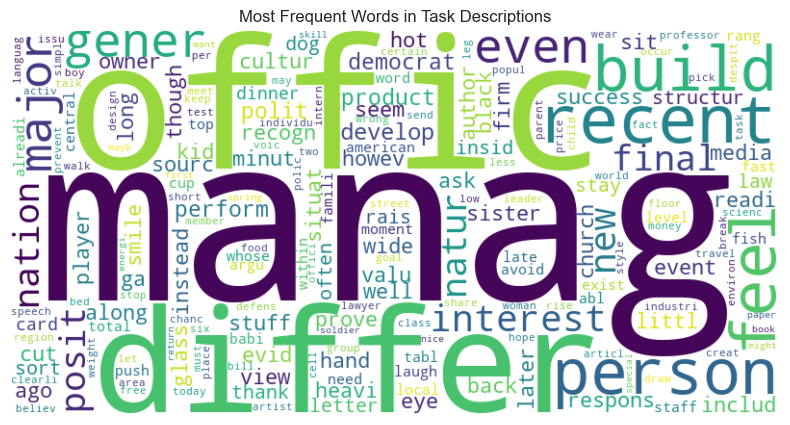

In [15]:
from wordcloud import WordCloud

all_text = " ".join(df['cleaned_description'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Task Descriptions")
plt.show()


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=500)
X_tfidf = vectorizer.fit_transform(df['task_description'])

print(X_tfidf.shape)  # (num_samples, num_features)


(1500, 500)


In [ ]:
import pandas as pd

df = pd.read_csv("synthetic_task_dataset.csv")
texts = df['task_description'].astype(str).tolist()

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np



vectorizer = TfidfVectorizer(
    lowercase=True,        
    ngram_range=(1,2),     
    max_features=20000,    
    min_df=3,               
    max_df=0.9,             
    sublinear_tf=True,      
    stop_words='english'   
)
X_tfidf = vectorizer.fit_transform(texts)  
print("TF-IDF shape:", X_tfidf.shape)


TF-IDF shape: (1500, 764)


In [18]:

import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import classification_report, accuracy_score, f1_score, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import string

from scipy.sparse import hstack
import matplotlib.pyplot as plt

In [19]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()  
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    tokens = word_tokenize(text)  
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]  # remove stopwords & stem
    return " ".join(tokens)

In [20]:


df=pd.read_csv("synthetic_task_dataset.csv")
print(df.columns)
print(df.info)

Index(['task_id', 'task_title', 'task_description', 'priority', 'deadline',
       'assigned_to', 'status', 'category', 'estimated_hours', 'created_at'],
      dtype='object')
<bound method DataFrame.info of       task_id                            task_title  \
0           1            Opportunity item indicate.   
1           2                    Wish article hand.   
2           3                        Dinner system.   
3           4                    Sort right parent.   
4           5  Type knowledge question there drive.   
...       ...                                   ...   
1495     1496       Scene rather probably set tend.   
1496     1497                       Big face these.   
1497     1498                      Image land very.   
1498     1499             Next lot radio event end.   
1499     1500                Condition head choice.   

                                       task_description priority    deadline  \
0     Property agreement position. Decide hundred c

In [21]:
texts = df['task_description'].astype(str)
labels = df['category'].astype(str)   # ⚠️ replace 'category' with your label column name


In [22]:

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)
X_text = tfidf.fit_transform(df['task_description'])

In [23]:
print(df.columns.to_list())

['task_id', 'task_title', 'task_description', 'priority', 'deadline', 'assigned_to', 'status', 'category', 'estimated_hours', 'created_at']


In [24]:

for col in ['priority_score', 'estimated_hours', 'actual_hours',
            'user_workload_hours', 'days_until_due', 'word_count', 'efficiency_ratio']:
    if col not in df.columns:
        df[col] = 0

numeric_features = [
    'priority_score', 'estimated_hours', 'actual_hours',
    'user_workload_hours', 'days_until_due', 'word_count', 'efficiency_ratio'
]


df[numeric_features] = df[numeric_features].fillna(0)
X = hstack([X_text, df[numeric_features].values])

In [25]:
numeric_features = [
    'priority_score', 'estimated_hours', 'actual_hours',
    'user_workload_hours', 'days_until_due', 'word_count', 'efficiency_ratio'
]

for col in numeric_features:
    if col not in df.columns:
        df[col] = 0  # creates missing numeric columns as 0s

df[numeric_features] = df[numeric_features].fillna(0)

from scipy.sparse import hstack
X = hstack([X_text, df[numeric_features].values])


In [26]:
y = df['category']   # ⚠️ change 'category' to your actual label column name

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



In [27]:
X_train.shape

(1200, 976)

In [28]:
# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

In [29]:
# SVM
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [30]:
print("Naive Bayes Performance")
print(classification_report(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Performance
               precision    recall  f1-score   support

      Bug Fix       0.17      0.16      0.17        62
Documentation       0.17      0.09      0.12        56
      Feature       0.21      0.34      0.26        64
      Testing       0.19      0.23      0.21        61
        UI/UX       0.22      0.12      0.16        57

     accuracy                           0.19       300
    macro avg       0.19      0.19      0.18       300
 weighted avg       0.19      0.19      0.18       300

Accuracy: 0.19333333333333333


In [31]:
#Evaluate Models for Naive Bayes
print(classification_report(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

               precision    recall  f1-score   support

      Bug Fix       0.18      0.18      0.18        62
Documentation       0.12      0.11      0.12        56
      Feature       0.20      0.22      0.21        64
      Testing       0.21      0.26      0.23        61
        UI/UX       0.24      0.19      0.21        57

     accuracy                           0.19       300
    macro avg       0.19      0.19      0.19       300
 weighted avg       0.19      0.19      0.19       300

Accuracy: 0.19333333333333333
